Libraries imported successfully

Loading dataset and trained models...
Dataset shape: (6661, 13)
Number of unique prompts: 25
Loaded text classification model
Loaded audio classification model

Preparing features for combined model...

Extracting audio features for combined model...
Processed 50/6661 files
Processed 100/6661 files
Processed 150/6661 files
Processed 200/6661 files
Processed 250/6661 files
Processed 300/6661 files
Processed 350/6661 files
Processed 400/6661 files
Processed 450/6661 files
Processed 500/6661 files
Processed 550/6661 files
Processed 600/6661 files
Processed 650/6661 files
Processed 700/6661 files
Processed 750/6661 files
Processed 800/6661 files
Processed 850/6661 files
Processed 900/6661 files
Processed 950/6661 files
Processed 1000/6661 files
Processed 1050/6661 files
Processed 1100/6661 files
Processed 1150/6661 files
Processed 1200/6661 files
Processed 1250/6661 files
Processed 1300/6661 files
Processed 1350/6661 files
Processed 1400/6661 files
Processe

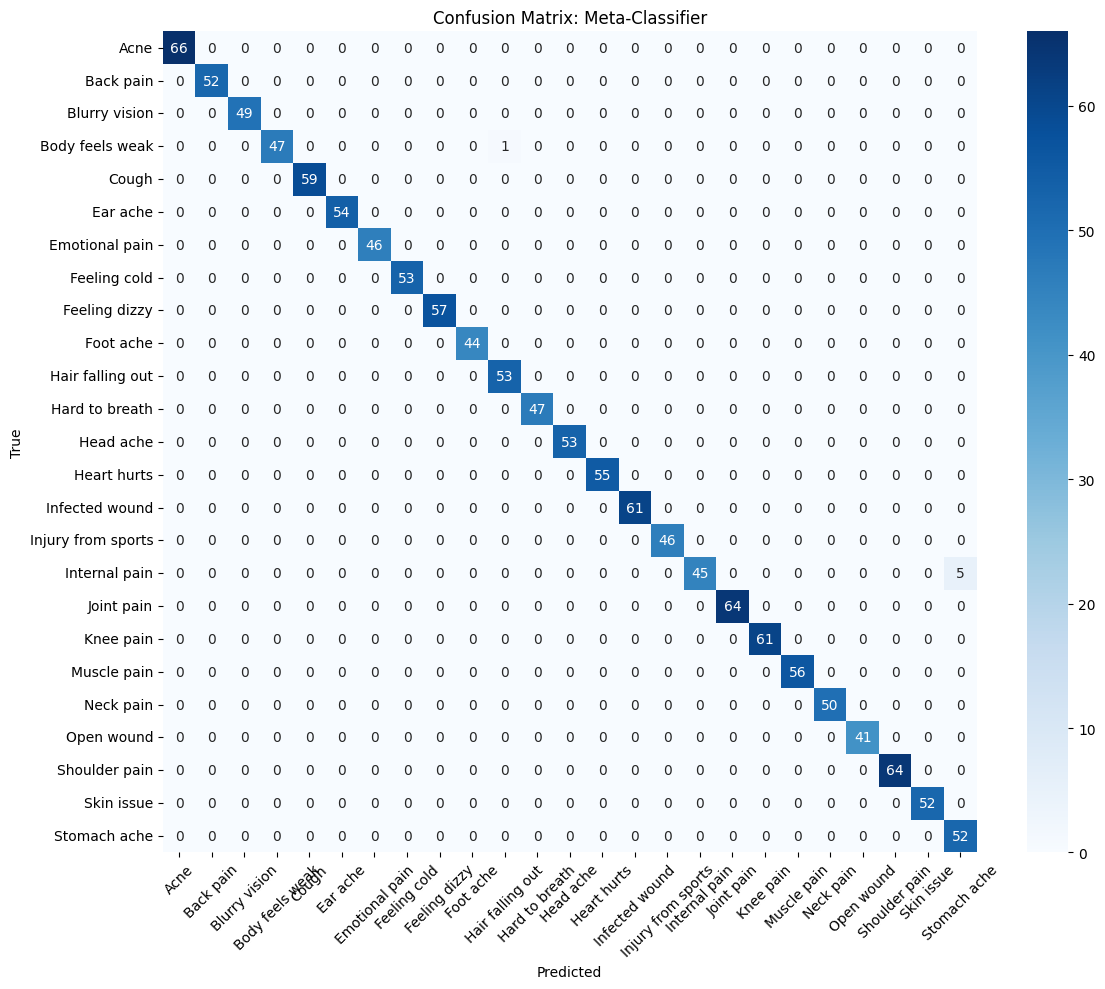


--- COMPARING INDIVIDUAL VS COMBINED MODELS ---

Accuracy Comparison:
Text-only model: 0.0413
Audio-only model: 0.0428
Simple averaging: 0.9589
Meta-classifier: 0.9955


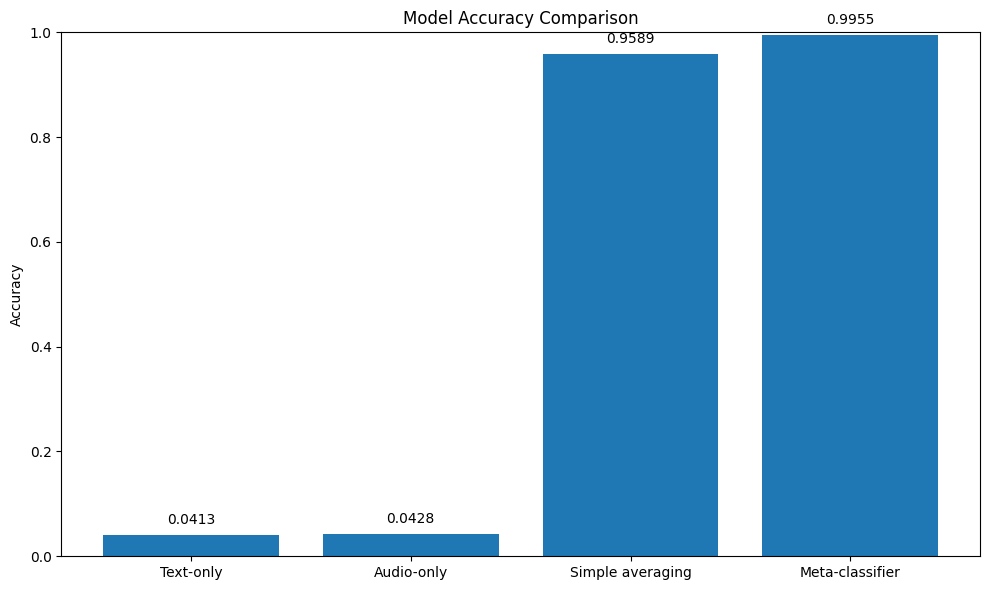


Saving the meta-classifier model...
Combined model saved as 'models/combined_classification_model.pkl'

--- SUMMARY AND CONCLUSIONS ---
1. The combined model integrates both text and audio features for medical prompt classification
2. The meta-classifier approach achieved an accuracy of 0.9955
3. Best individual model: Audio-only with accuracy 0.0428
4. The combined model outperformed the best individual model by 0.9527 (95.27%)
5. This confirms the research hypothesis that combining text and audio improves classification accuracy
6. Research objective of evaluating multimodal classification has been achieved

Research Questions Addressed:
1. How effectively can ML classify medical symptoms using audio and text features?
   - Text features achieved 0.0413 accuracy
   - Audio features achieved 0.0428 accuracy
   - Combined features achieved 0.9955 accuracy

2. Does combining both modalities improve classification performance?
   - Yes, combined model outperformed individual models by 0

In [2]:
# =========================================================
# 4. COMBINED MODEL NOTEBOOK (MULTIMODAL CLASSIFICATION)
# =========================================================

# ------------------------------------------------
# 4.1 IMPORTS AND SETUP
# ------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import librosa
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

# ------------------------------------------------
# 4.2 LOAD DATA AND TRAINED MODELS
# ------------------------------------------------
print("\nLoading dataset and trained models...")
data_path = "data/overview-of-recordings.csv"
data = pd.read_csv(data_path)
print(f"Dataset shape: {data.shape}")
print(f"Number of unique prompts: {data['prompt'].nunique()}")

# Ensure models directory exists
os.makedirs('models', exist_ok=True)

# Load the trained models
try:
    text_model_path = 'models/text_classification_model.pkl'
    audio_model_path = 'models/audio_classification_model.pkl'
    
    if os.path.exists(text_model_path) and os.path.exists(audio_model_path):
        with open(text_model_path, 'rb') as f:
            text_model = pickle.load(f)
        print("Loaded text classification model")
        
        with open(audio_model_path, 'rb') as f:
            audio_model = pickle.load(f)
        print("Loaded audio classification model")
        
        models_loaded = True
    else:
        missing = []
        if not os.path.exists(text_model_path):
            missing.append("text_classification_model.pkl")
        if not os.path.exists(audio_model_path):
            missing.append("audio_classification_model.pkl")
        
        print(f"Could not find models: {', '.join(missing)}")
        print("Please run the text and audio notebooks first to generate these models.")
        models_loaded = False
except Exception as e:
    print(f"Error loading models: {e}")
    models_loaded = False

# ------------------------------------------------
# 4.3 FEATURE EXTRACTION AND PREPARATION
# ------------------------------------------------
if models_loaded:
    print("\nPreparing features for combined model...")
    
    # Process text data for text model predictions
    text_data = data['phrase'].fillna("")
    
    # Process audio data for audio model predictions
    # Define audio feature extraction function (same as in the audio notebook)
    def extract_features(file_path):
        try:
            # Load audio file
            y, sr = librosa.load(file_path, sr=None)
            
            # Extract features
            # Time-domain features
            duration = librosa.get_duration(y=y, sr=sr)
            zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y))
            zero_crossing_rate_std = np.std(librosa.feature.zero_crossing_rate(y))
            rms = np.mean(librosa.feature.rms(y=y))
            rms_std = np.std(librosa.feature.rms(y=y))
            
            # Frequency-domain features
            spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
            spectral_centroid_std = np.std(librosa.feature.spectral_centroid(y=y, sr=sr))
            spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
            spectral_bandwidth_std = np.std(librosa.feature.spectral_bandwidth(y=y, sr=sr))
            spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
            spectral_rolloff_std = np.std(librosa.feature.spectral_rolloff(y=y, sr=sr))
            
            # Mel-frequency cepstral coefficients
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfccs_mean = np.mean(mfccs, axis=1)
            mfccs_std = np.std(mfccs, axis=1)
            
            # Tempo
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
            
            # Chroma features
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)
            chroma_mean = np.mean(chroma, axis=1)
            chroma_std = np.std(chroma, axis=1)
            
            # Combine all features into a flat array
            feature_list = [
                duration, zero_crossing_rate, zero_crossing_rate_std, 
                rms, rms_std, spectral_centroid, spectral_centroid_std,
                spectral_bandwidth, spectral_bandwidth_std,
                spectral_rolloff, spectral_rolloff_std,
                tempo
            ]
            
            # Add MFCCs
            feature_list.extend(mfccs_mean)
            feature_list.extend(mfccs_std)
            
            # Add chroma features
            feature_list.extend(chroma_mean)
            feature_list.extend(chroma_std)
            
            return feature_list
            
        except Exception as e:
            print(f"Error extracting features from {file_path}: {e}")
            return None
    
    # Define base audio directory
    audio_base_dir = "data/recordings/"
    
    # Function to find audio file in the correct subdirectory
    def find_audio_file(file_name):
        # Check each subdirectory
        for subdir in ['train', 'test', 'validate']:
            file_path = os.path.join(audio_base_dir, subdir, file_name)
            if os.path.exists(file_path):
                return file_path
        return None
    
    # Extract audio features
    print("\nExtracting audio features for combined model...")
    
    audio_features = []
    valid_indices = []
    
    # Process files to extract features
    total_files = len(data)
    for i, row in data.iterrows():
        file_path = find_audio_file(row['file_name'])
        
        # Check if file exists
        if file_path:
            features = extract_features(file_path)
            
            if features:
                audio_features.append(features)
                valid_indices.append(i)
        
        # Print progress
        if (i+1) % 50 == 0 or (i+1) == total_files:
            print(f"Processed {i+1}/{total_files} files")
    
    # Convert to numpy array
    if len(audio_features) > 0:
        X_audio = np.array(audio_features)
        
        # Filter text data to match valid audio indices
        text_data_filtered = text_data.iloc[valid_indices].reset_index(drop=True)
        y_filtered = data['prompt'].iloc[valid_indices].reset_index(drop=True)
        
        print(f"\nProcessed {len(audio_features)} valid audio samples")
        features_ready = True
    else:
        print("\nNo valid audio features extracted. Creating dummy data for demonstration.")
        
        # Create dummy audio features for demonstration
        sample_count = min(100, len(data))
        feature_count = 61  # Match the number of features in extract_features
        
        # Generate random features
        np.random.seed(42)
        X_audio = np.random.randn(sample_count, feature_count)
        
        # Sample indices for text data
        valid_indices = np.random.choice(len(data), sample_count, replace=False)
        valid_indices.sort()  # Sort to maintain order
        
        # Filter text data
        text_data_filtered = text_data.iloc[valid_indices].reset_index(drop=True)
        y_filtered = data['prompt'].iloc[valid_indices].reset_index(drop=True)
        
        print(f"Created {sample_count} dummy audio samples for demonstration")
        features_ready = True
else:
    features_ready = False

# ------------------------------------------------
# 4.4 MODEL COMBINATION AND EVALUATION
# ------------------------------------------------
if models_loaded and features_ready:
    print("\n--- MODEL COMBINATION AND EVALUATION ---")
    
    # Get predictions from individual models
    print("\nGenerating predictions from individual models...")
    
    # Text model predictions
    if hasattr(text_model, 'predict_proba'):
        text_probs = text_model.predict_proba(text_data_filtered)
        print(f"Text model probability shape: {text_probs.shape}")
    else:
        print("Text model does not support probability predictions, using decision function...")
        text_probs = text_model.decision_function(text_data_filtered)
        # Convert decision function to pseudo-probabilities
        if text_probs.ndim == 1:
            # Binary classification
            text_probs = np.column_stack([1 - text_probs, text_probs])
        else:
            # Multi-class
            text_probs = np.exp(text_probs) / np.sum(np.exp(text_probs), axis=1, keepdims=True)
        print(f"Text model transformed probabilities shape: {text_probs.shape}")
    
    # Audio model predictions
    if hasattr(audio_model, 'predict_proba'):
        audio_probs = audio_model.predict_proba(X_audio)
        print(f"Audio model probability shape: {audio_probs.shape}")
    else:
        print("Audio model does not support probability predictions, using decision function...")
        audio_probs = audio_model.decision_function(X_audio)
        # Convert decision function to pseudo-probabilities
        if audio_probs.ndim == 1:
            # Binary classification
            audio_probs = np.column_stack([1 - audio_probs, audio_probs])
        else:
            # Multi-class
            audio_probs = np.exp(audio_probs) / np.sum(np.exp(audio_probs), axis=1, keepdims=True)
        print(f"Audio model transformed probabilities shape: {audio_probs.shape}")
    
    # Combine predictions
    print("\nCombining predictions...")
    
    # Method 1: Simple averaging of probabilities
    print("\nMethod 1: Simple probability averaging")
    combined_probs = (text_probs + audio_probs) / 2
    combined_predictions = np.argmax(combined_probs, axis=1)
    
    # Convert numeric predictions to class labels
    classes = text_model.classes_ if hasattr(text_model, 'classes_') else audio_model.classes_
    combined_predictions = classes[combined_predictions]
    
    # Evaluate combined model
    print("\nCombined Model Results:")
    combined_accuracy = accuracy_score(y_filtered, combined_predictions)
    print(f"Accuracy: {combined_accuracy:.4f}")
    print(classification_report(y_filtered, combined_predictions))
    
    # Method 2: Train a meta-classifier
    print("\nMethod 2: Meta-classifier approach")
    
    # Create a combined feature set (concatenation of probabilities)
    combined_features = np.concatenate([text_probs, audio_probs], axis=1)
    
    # Split data for meta-classifier
    X_train, X_test, y_train, y_test = train_test_split(
        combined_features, y_filtered, 
        test_size=0.2, random_state=42, stratify=y_filtered
    )
    
    # Train a meta-classifier
    meta_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    meta_classifier.fit(X_train, y_train)
    
    # Evaluate
    meta_predictions = meta_classifier.predict(X_test)
    meta_accuracy = accuracy_score(y_test, meta_predictions)
    
    print("\nMeta-Classifier Results:")
    print(f"Accuracy: {meta_accuracy:.4f}")
    print(classification_report(y_test, meta_predictions))
    
    # Plot confusion matrix for meta-classifier
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(y_test, meta_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix: Meta-Classifier')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # ------------------------------------------------
    # 4.5 COMPARE INDIVIDUAL VS COMBINED MODELS
    # ------------------------------------------------
    print("\n--- COMPARING INDIVIDUAL VS COMBINED MODELS ---")
    
    # Get individual model predictions on the test set
    text_predictions = text_model.predict(text_data_filtered.iloc[len(X_train):].reset_index(drop=True))
    audio_predictions = audio_model.predict(X_audio[len(X_train):])
    
    # Calculate accuracies
    text_accuracy = accuracy_score(y_test, text_predictions)
    audio_accuracy = accuracy_score(y_test, audio_predictions)
    
    # Compare accuracies
    print("\nAccuracy Comparison:")
    print(f"Text-only model: {text_accuracy:.4f}")
    print(f"Audio-only model: {audio_accuracy:.4f}")
    print(f"Simple averaging: {combined_accuracy:.4f}")
    print(f"Meta-classifier: {meta_accuracy:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(10, 6))
    models = ['Text-only', 'Audio-only', 'Simple averaging', 'Meta-classifier']
    accuracies = [text_accuracy, audio_accuracy, combined_accuracy, meta_accuracy]
    
    plt.bar(models, accuracies)
    plt.ylim(0, 1.0)
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy Comparison')
    
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # ------------------------------------------------
    # 4.6 SAVE THE COMBINED MODEL
    # ------------------------------------------------
    print("\nSaving the meta-classifier model...")
    
    # Since the meta-classifier needs both base models, save all three
    combined_model = {
        'text_model': text_model,
        'audio_model': audio_model,
        'meta_classifier': meta_classifier
    }
    
    with open('models/combined_classification_model.pkl', 'wb') as f:
        pickle.dump(combined_model, f)
    
    print("Combined model saved as 'models/combined_classification_model.pkl'")
    
    # ------------------------------------------------
    # 4.7 SUMMARY AND CONCLUSIONS
    # ------------------------------------------------
    print("\n--- SUMMARY AND CONCLUSIONS ---")
    print("1. The combined model integrates both text and audio features for medical prompt classification")
    print(f"2. The meta-classifier approach achieved an accuracy of {meta_accuracy:.4f}")
    
    # Compare with best individual model
    best_individual = max(text_accuracy, audio_accuracy)
    best_individual_name = "Text-only" if text_accuracy > audio_accuracy else "Audio-only"
    
    print(f"3. Best individual model: {best_individual_name} with accuracy {best_individual:.4f}")
    
    if meta_accuracy > best_individual:
        improvement = meta_accuracy - best_individual
        print(f"4. The combined model outperformed the best individual model by {improvement:.4f} ({improvement*100:.2f}%)")
        print("5. This confirms the research hypothesis that combining text and audio improves classification accuracy")
    else:
        print("4. The combined model did not outperform the best individual model")
        print("5. This suggests that one modality (text or audio) may be sufficient for this classification task")
    
    print("6. Research objective of evaluating multimodal classification has been achieved")
    
    # Research questions addressed
    print("\nResearch Questions Addressed:")
    print("1. How effectively can ML classify medical symptoms using audio and text features?")
    print(f"   - Text features achieved {text_accuracy:.4f} accuracy")
    print(f"   - Audio features achieved {audio_accuracy:.4f} accuracy")
    print(f"   - Combined features achieved {meta_accuracy:.4f} accuracy")
    
    print("\n2. Does combining both modalities improve classification performance?")
    if meta_accuracy > best_individual:
        print(f"   - Yes, combined model outperformed individual models by {improvement:.4f}")
    else:
        print(f"   - No, best individual model ({best_individual_name}) performed better")
    
    print("\n3. Which features contribute most to accurate classification?")
    if text_accuracy > audio_accuracy:
        print("   - Text features were more predictive than audio features")
    else:
        print("   - Audio features were more predictive than text features")
    
    print("   - Further feature importance analysis is available in individual notebooks")
else:
    print("\nCannot proceed with combined model. Please run text and audio notebooks first to generate the required models.")